<a href="https://colab.research.google.com/github/helonayala/sysid/blob/main/narmax_example_drone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NARX model

NARX model for the 1/4 drone dataset.

## Imports, functions, and classes

In [1]:
# Imports and sysid course library
import numpy as np
import matplotlib.pyplot as plt

# --- Install/import the sysid course library (works locally and on Google Colab) ---
try:
    from sysid import NARX, readData
except ImportError:
    !pip install -q git+https://github.com/helonayala/sysid.git
    from sysid import NARX, readData


## Read 1/4 drone data

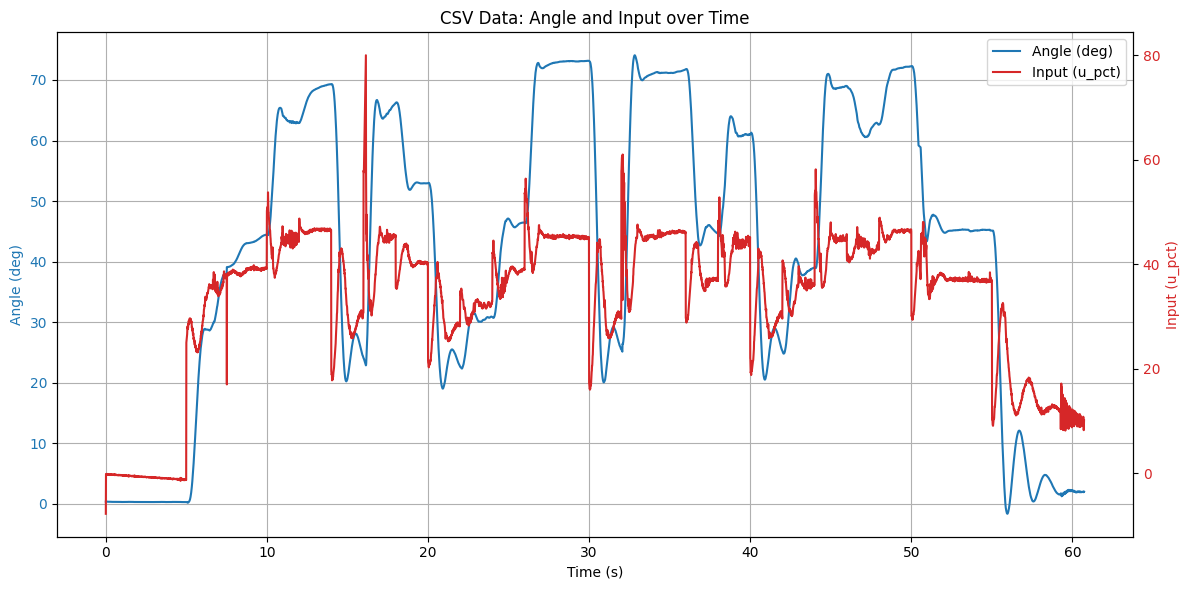

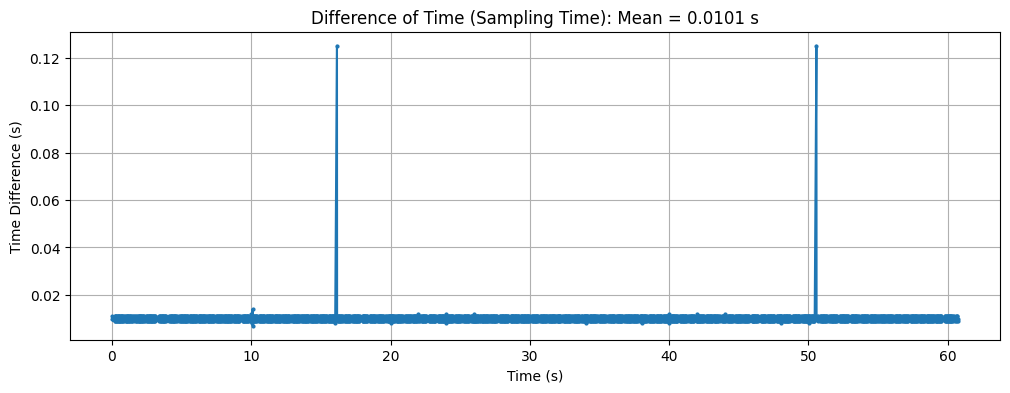

In [2]:
# Load our original 1/4 drone sequence data (y, u, time)
ye, ue, timee = readData("quarter_drone", "seq")

# Plotting the loaded CSV data with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(timee, ye, label='Angle (deg)', color='tab:blue')
ax1.set_ylabel('Angle (deg)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title('CSV Data: Angle and Input over Time')
ax1.set_xlabel('Time (s)')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(timee, ue, label='Input (u_pct)', color='tab:red')
ax2.set_ylabel('Input (u_pct)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.tight_layout()
plt.show()

# Plotting the difference of 'timee' to check sampling time
plt.figure(figsize=(12, 4))
timee_diff = np.diff(timee)
mean_timee_diff = np.mean(timee_diff) # Calculate mean here
plt.plot(timee[1:], timee_diff, 'o-', markersize=2)
plt.title(f'Difference of Time (Sampling Time): Mean = {mean_timee_diff:.4f} s') # Use mean in title
plt.xlabel('Time (s)')
plt.ylabel('Time Difference (s)')
plt.grid(True)
plt.show()

### Processed CSV Data: Slicing and Decimation

Original data length: 6039
Requested time range: [4.0s, 50.0s]
Sliced data length: 4581 (from 4.01s to 50.00s)
Decimated data length (factor 5): 917


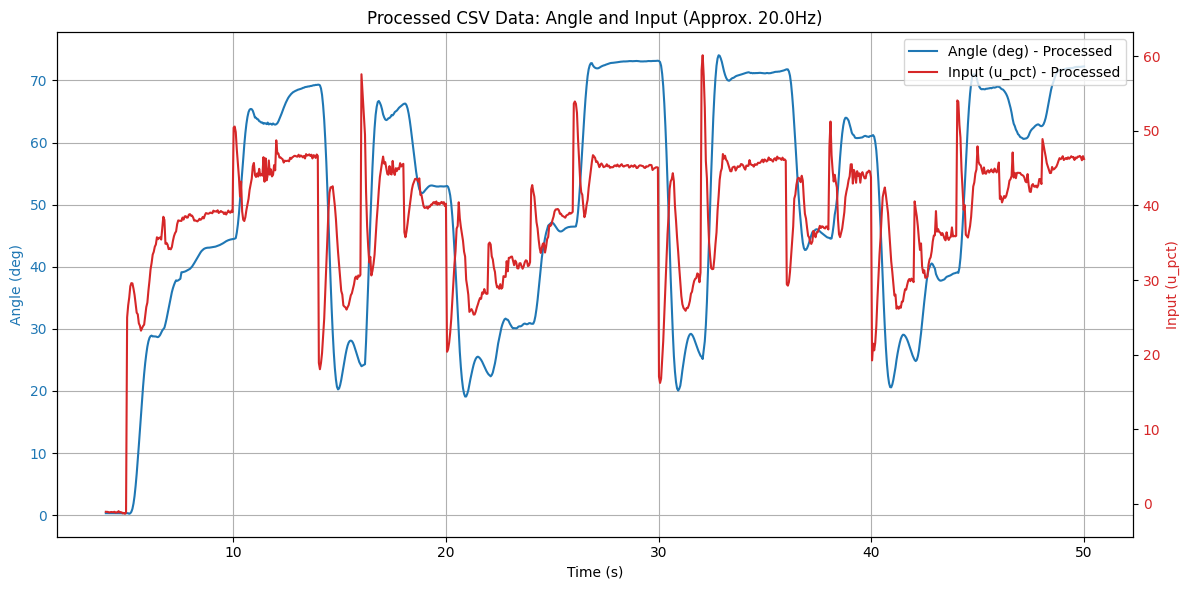

In [3]:
# 1. Slice the vectors from a specified time range (seconds)
start_time_s = 4.0
end_time_s = 50.0

# User-defined decimation factor
decimation_factor = 5  # Set this to 2, 5, 10, etc.

start_idx = np.searchsorted(timee, start_time_s)
end_idx = np.searchsorted(timee, end_time_s)

if start_idx >= len(timee): start_idx = len(timee) - 1
if end_idx >= len(timee): end_idx = len(timee) - 1
if timee[end_idx] > end_time_s and end_idx > 0:
    end_idx -= 1

if start_idx > end_idx:
    print(f"Warning: The requested time range [{start_time_s}s, {end_time_s}s] "
          f"is outside the available data range [{timee[0]}s, {timee[-1]}s].")
    print("Returning empty arrays for t, u, y.")
    t, u, y = np.array([]), np.array([]), np.array([])
else:
    timee_sliced = timee[start_idx : end_idx + 1]
    ue_sliced = ue[start_idx : end_idx + 1]
    ye_sliced = ye[start_idx : end_idx + 1]

    t = timee_sliced[::decimation_factor]
    u = ue_sliced[::decimation_factor]
    y = ye_sliced[::decimation_factor]

    print(f"Original data length: {len(timee)}")
    print(f"Requested time range: [{start_time_s}s, {end_time_s}s]")
    print(f"Sliced data length: {len(timee_sliced)} (from {timee_sliced[0]:.2f}s to {timee_sliced[-1]:.2f}s)")
    print(f"Decimated data length (factor {decimation_factor}): {len(t)}")


# 2. Plot the processed (sliced and decimated) data using t, u, y
fig, ax1 = plt.subplots(figsize=(12, 6))

if t.size > 0:
    ax1.plot(t, y, label='Angle (deg) - Processed', color='tab:blue')
    ax1.set_ylabel('Angle (deg)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    original_sampling_freq = 100  # Hz (approx 0.01 s per sample for original CSV)
    decimated_sampling_freq = original_sampling_freq / decimation_factor
    ax1.set_title(f'Processed CSV Data: Angle and Input (Approx. {decimated_sampling_freq:.1f}Hz)')
    ax1.set_xlabel('Time (s)')
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(t, u, label='Input (u_pct) - Processed', color='tab:red')
    ax2.set_ylabel('Input (u_pct)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper right')
else:
    ax1.set_title('No data to plot after slicing and decimation')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Value')

plt.tight_layout()
plt.show()


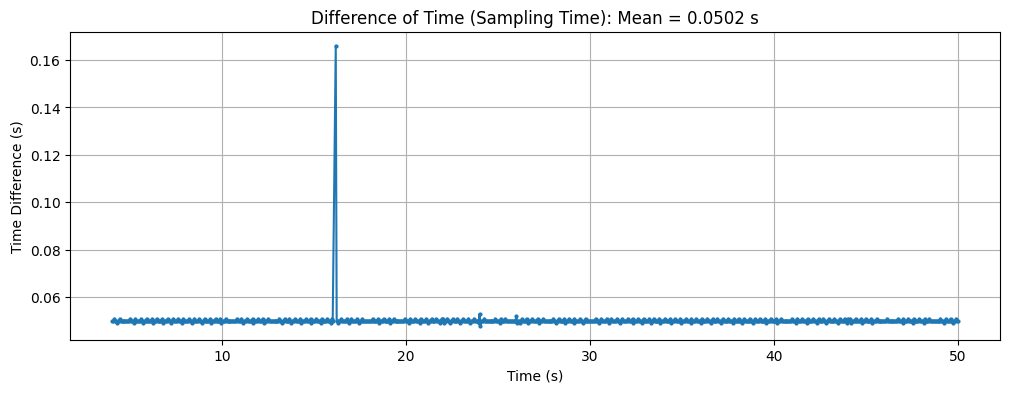

In [4]:
plt.figure(figsize=(12, 4))
t_diff = np.diff(t)
mean_sampling_time = np.mean(t_diff)
plt.plot(t[1:], t_diff, 'o-', markersize=2)
plt.title(f'Difference of Time (Sampling Time): Mean = {mean_sampling_time:.4f} s')
plt.xlabel('Time (s)')
plt.ylabel('Time Difference (s)')
plt.grid(True)
plt.show()


## Define model parameters, call constructor, and run estimation

In [5]:
no_of_terms = 5
nu_model = 5
ny_model = 5
poly_order_model = 3

# 3. Instantiate and fit the NARX model
narx_model = NARX(nu=nu_model, ny=ny_model, poly_order_l=poly_order_model, n_components=no_of_terms)
narx_model.fit(u, y)

narx_model.print()


NARX model — selected terms and parameters
Max lag: 5  (ny=5, nu=5, l=3)
#    Term                                theta     ERR (%)
-------------------------------------------------------
1    y(k-1)                             1.9373   99.944611
2    y(k-2)                            -0.9545    0.052317
3    u(k-2)u(k-2)                       0.0007    0.001981
4    u(k-4)u(k-5)u(k-5)                 0.0000    0.000148
5    u(k-2)u(k-3)                      -0.0004    0.000036
-------------------------------------------------------
Total ERR explained:                 99.999093%


## Free-Run (FR) Simulation

In [6]:
max_lag = narx_model._max_lag_internal_

# estimation, not so difficult
ye_fr = y[max_lag:] # Target for the FR part
ye_hat = narx_model.predict(u, y_history_for_lags_or_osa=ye[:max_lag], mode='FR')


Starting Free-Run Simulation for 912 steps...


FR Simulation:   0%|          | 0/912 [00:00<?, ?step/s]

### Sampling time of the NARX model

In [7]:
sampling_time_ms = (1 / original_sampling_freq) * 1000 * decimation_factor
print(f"The sampling time used to create the NARX model is {sampling_time_ms:.2f} ms.")

The sampling time used to create the NARX model is 50.00 ms.


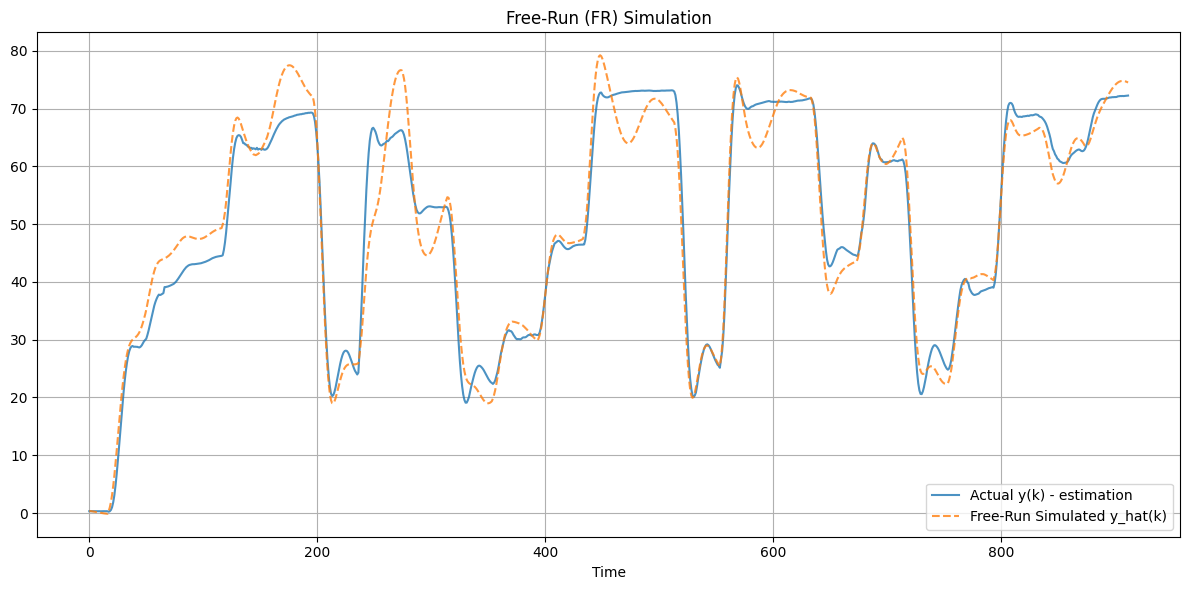

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(ye_fr, label='Actual y(k) - estimation', alpha=0.8)
plt.plot(ye_hat, label='Free-Run Simulated y_hat(k)', linestyle='--', alpha=0.8)
plt.title(f'Free-Run (FR) Simulation')
plt.xlabel(f'Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
